# 5. Exponential Growth

## Introduction

This notebook complements the chapter on exponential growth. We simulate stochastic individual replication using different probability distributions for generation times to demonstrate how exponential dynamics emerge at the population level.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, geom

## Simulation Algorithm

### The Core Logic: The "Clock" Mechanism
The algorithm simulates time in discrete steps, or "ticks." Each organism tracks the time remaining until its next reproduction event using an internal clock.

The simulation initializes with $N_{init}$ organisms. To avoid biologically unrealistic synchronization, each organism starts with a random age. During the aging step, the algorithm subtracts 1 from every organism's clock.

When an organism's clock reaches zero, a birth event is triggered, simulating binary fission or budding. This involves two simultaneous actions: the parent organism resets with a new "cooldown" period, and a new offspring is added to the population with its own fresh cooldown period. This cycle repeats until the population reaches a predefined carrying capacity, $N_{max}$.

### Understanding the Three Growth Regimes
The method chosen to assign the "cooldown" period determines the biological nature of the simulation:

1. Deterministic (Fixed Age) In this regime, every organism reproduces at the exact same interval. This simulates highly synchronized laboratory cultures. 
2. Poisson (Variable Age) Here, the time until reproduction follows a Poisson-like distribution. This represents organisms that generally reproduce at a specific age but are subject to metabolic noise or environmental delays.
3. Geometric/Memoryless (Constant Rate) In this scenario, an organism has a fixed probability of reproducing at any moment, independent of its age.

In [2]:
def exponentialGrowth(N_init, N_max, repAge, mode='fixed', cd_plots=False):
    # Initialize living individuals
    pop = np.random.randint(1, repAge + 1, size=N_init)
    n_history = [N_init]
    
    # Define fixed bin edges for consistent PDF calculation across steps
    bin_edges = np.linspace(0, 2 * repAge, 21)  # 21 edges define 20 bins
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    #if cd_plots:
    #    plt.figure(figsize=(8, 5))
    
    while len(pop) < N_max:
        # Compute and plot clock distribution (PDF) for current step
        if cd_plots and len(pop) > 0:
            pdf, _ = np.histogram(pop, bins=bin_edges, density=True)
            plt.plot(bin_centers, pdf, color='C0', alpha=0.1)

        # 1. Aging step: Decrement all timers at once
        pop -= 1
        
        # 2. Identify who is ready to reproduce (timer reached 0)
        repro_mask = pop <= 0
        num_newborns = np.sum(repro_mask)
        
        if num_newborns > 0:
            # Prevent exceeding N_max
            space_left = N_max - len(pop)
            actual_newborns = min(num_newborns, space_left)
            
            # 3. Generate new wait times based on the mode
            if mode == 'fixed':
                new_clocks = np.full(num_newborns + actual_newborns, repAge)
            elif mode == 'poisson':
                # +1 to ensure no 0-step immediate reproduction
                new_clocks = np.random.poisson(repAge, size=num_newborns + actual_newborns) + 1
            elif mode == 'geometric':
                p = np.log(2) / repAge
                new_clocks = np.random.geometric(p, size=num_newborns + actual_newborns)
            
            # 4. Update parent clocks and append newborns
            pop[repro_mask] = new_clocks[:num_newborns]
            pop = np.concatenate([pop, new_clocks[num_newborns : num_newborns + actual_newborns]])
        
        n_history.append(len(pop))
        
        # Safety break if population goes extinct
        if len(pop) == 0:
            break
            
    if cd_plots:
        # Final formatting for the PDF evolution plot
        plt.xlabel('Clock Value')
        plt.ylabel('Probability Density')
        plt.title(f'Clock Value PDF Evolution (Mode: {mode})')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

    return n_history

## Comparison of model results

* **Deterministic:** The population grows in discrete "pulses."
* **Poisson:** The "stair-steps" of the growth curve blur, resulting in a more fluid expansion that retains an underlying rhythm.
* **Geometric:** This regime produces a smooth, classic exponential curve following an initial surge.

Despite these differences in fine-grained dynamics, all three regimes ultimately exhibit exponential growth.

This stands in marked contrast to exponential decay. In a growing population, the continuous addition of new individuals allows the age distribution to converge to a stationary state, which drives exponential growth regardless of the individual replication cycle. In a purely decaying population (without births), there is no mechanism to establish a stationary age structure; consequently, the aggregate decay pattern remains highly sensitive to the specific distribution of individual lifespans.

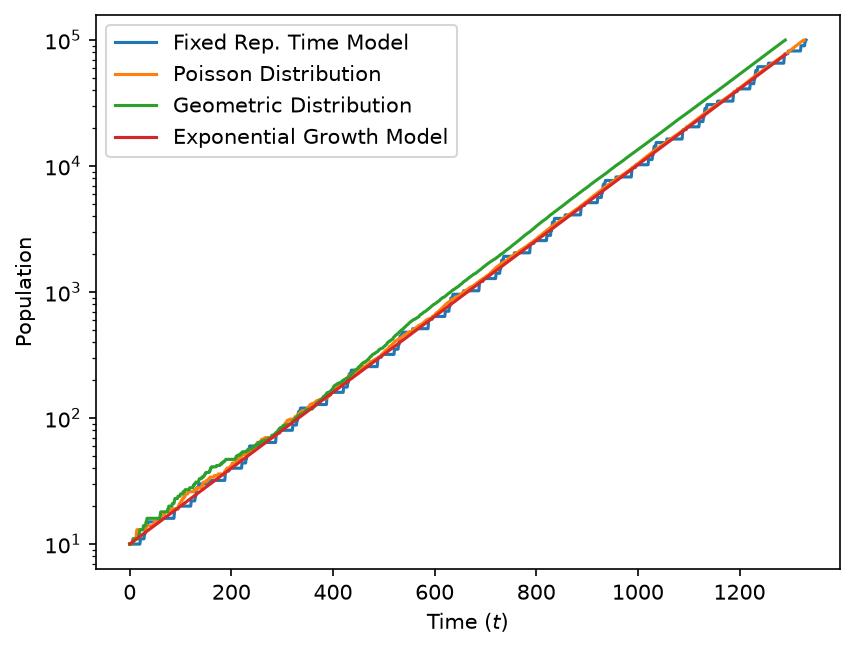

In [10]:
fig, ax = plt.subplots()
N_init = 10
N_max = 100000
repAge = 100

N = exponentialGrowth(N_init, N_max, repAge, mode='fixed')
ax.semilogy(N, label="Fixed Rep. Time Model")
N = exponentialGrowth(N_init, N_max, repAge, mode='poisson')
ax.semilogy(N, label="Poisson Distribution")
N = exponentialGrowth(N_init, N_max, repAge, mode='geometric')
ax.semilogy(N, label="Geometric Distribution")
ax.semilogy(N_init*np.exp(np.arange(len(N))*np.log(2)/repAge), label="Exponential Growth Model")

ax.set_xlabel(r"Time ($t$)")
ax.set_ylabel(r"Population")
ax.legend()

## Why all all stochastic models eventually approach the deterministic exponential growth?

When the argument `cd_plots` is set to `True`, the probability density functions of individual reproduction clock values ara ploted for every simulation step. We can see that the the system eventually evolves to a stationary PDF, regardless of the way the initial clock values are assigned to new borns.

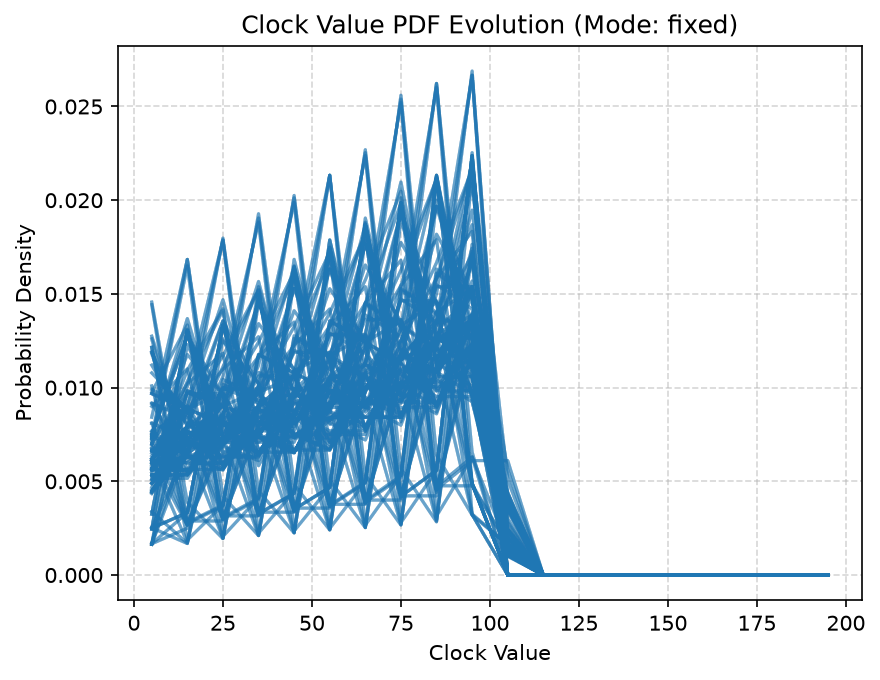

In [16]:
fig, ax = plt.subplots()
N_init = 100
N_max = 100000
repAge = 100

N = exponentialGrowth(N_init, N_max, repAge, mode='fixed', cd_plots=True)


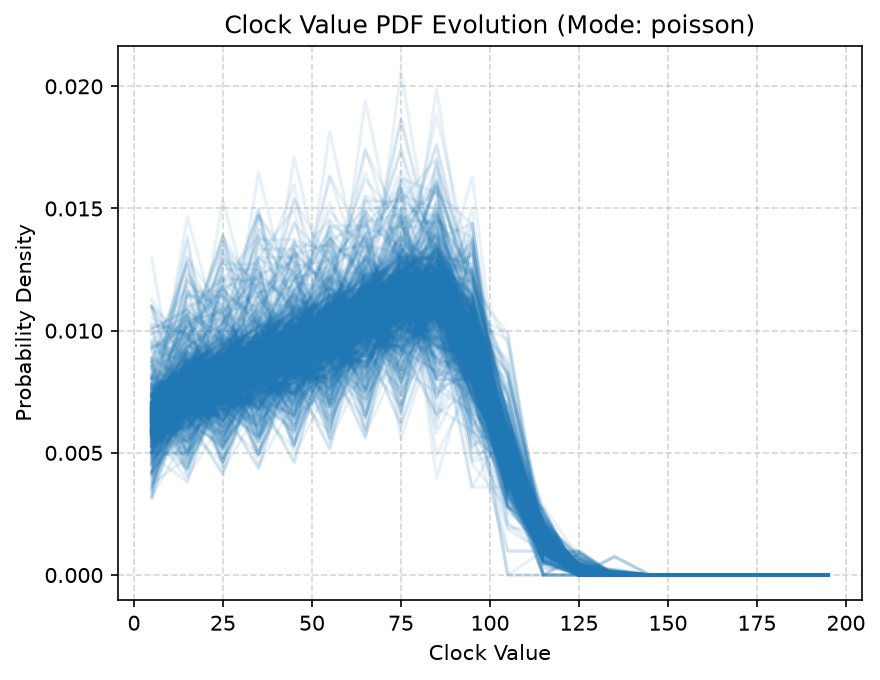

In [11]:
fig, ax = plt.subplots()
N_init = 100
N_max = 100000
repAge = 100

N = exponentialGrowth(N_init, N_max, repAge, mode='poisson', cd_plots=True)


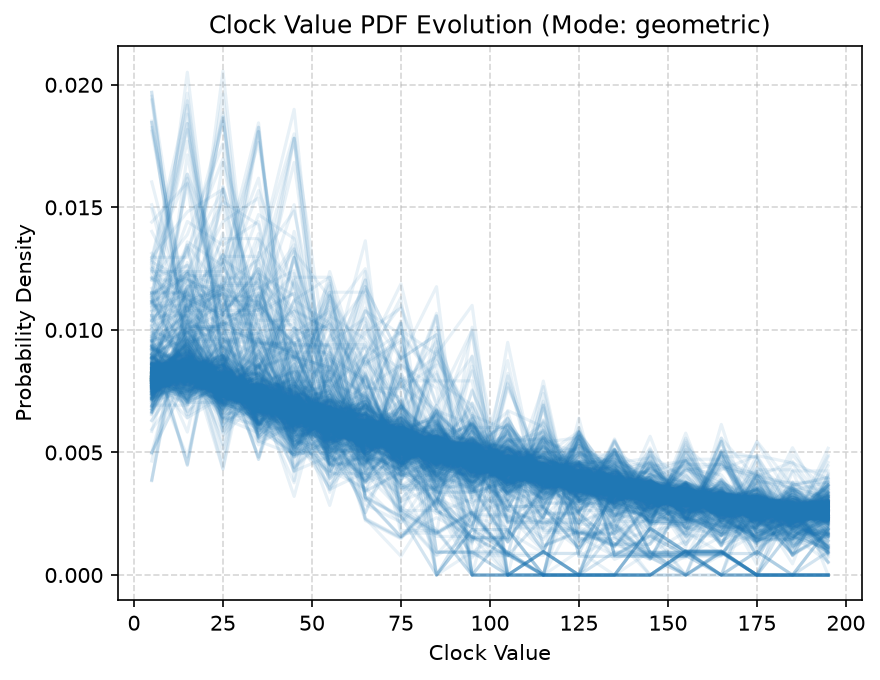

In [12]:
fig, ax = plt.subplots()
N_init = 100
N_max = 100000
repAge = 100

N = exponentialGrowth(N_init, N_max, repAge, mode='geometric', cd_plots=True)
